In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Statistical Modeling
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Deep Learning Modeling
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [15]:
# ==========================================
# STEP 1: DATA LOADING & SPLITTING
# ==========================================
print("--- Step 1: Loading and Splitting Data ---")
ticker = "TSLA"

--- Step 1: Loading and Splitting Data ---


In [16]:
# 1. Download data (auto_adjust=False to keep Adj Close)
data = yf.download(ticker, start="2015-01-01", end="2026-01-16", auto_adjust=False)

# 2. Robustly flatten the MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(level=1)

# 3. Clean column names to remove metadata/hidden names
data.columns = [str(col).strip() for col in data.columns]

[*********************100%***********************]  1 of 1 completed


In [17]:
# 4. Select the column with a fallback to 'Close'
if 'Adj Close' in data.columns:
    df = data[['Adj Close']].copy()
else:
    print("Warning: 'Adj Close' not found, using 'Close' instead.")
    df = data[['Close']].copy()
    df.columns = ['Adj Close']

In [18]:
# 5. Split chronologically (Train: 2015-2024 | Test: 2025-2026)
train_df = df[:"2024-12-31"].copy()
test_df = df["2025-01-01":].copy()

print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")


Training set size: 2516
Testing set size: 260


In [19]:
# ==========================================
# STEP 2.1: SARIMA MODEL (Statistical)
# ==========================================
print("\n--- Step 2.1: Fitting SARIMA Model ---")

# Find the best parameters automatically
sarima_model = auto_arima(train_df['Adj Close'], 
                          seasonal=True, m=5, 
                          stepwise=True, 
                          suppress_warnings=True, 
                          error_action='ignore', 
                          trace=True)

print(f"Best SARIMA Order: {sarima_model.order}")

# Forecast for the length of the test period
sarima_forecast_values = sarima_model.predict(n_periods=len(test_df))
sarima_forecast = pd.Series(sarima_forecast_values.values, index=test_df.index)


--- Step 2.1: Fitting SARIMA Model ---
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=16362.023, Time=2.25 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.19 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=16374.410, Time=1.51 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept   : AIC=16374.645, Time=1.57 sec
 ARIMA(2,1,2)(2,0,1)[5] intercept   : AIC=16363.452, Time=3.16 sec
 ARIMA(2,1,2)(1,0,2)[5] intercept   : AIC=16363.663, Time=3.50 sec
 ARIMA(2,1,2)(0,0,0)[5] intercept   : AIC=16374.056, Time=1.01 sec
 ARIMA(2,1,2)(0,0,2)[5] intercept   : AIC=16365.744, Time=2.10 sec
 ARIMA(2,1,2)(2,0,0)[5] intercept   : AIC=16367.551, Time=2.11 sec
 ARIMA(2,1,2)(2,0,2)[5] intercept   : AIC=16361.648, Time=3.72 sec
 ARIMA(1,1,2)(2,0,2)[5] intercept   : AIC=1636

d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [20]:
# ==========================================
# STEP 2.2: LSTM MODEL (Deep Learning)
# ==========================================
print("\n--- Step 2.2: Fitting LSTM Model ---")

# 1. Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_df[['Adj Close']])

# 2. Function to create sequences (Sliding Window)
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(scaled_train, window_size)

# Reshape for LSTM: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


--- Step 2.2: Fitting LSTM Model ---


In [21]:
# 3. Build LSTM Architecture
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
print("Training LSTM... (please wait)")
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0) 

d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM... (please wait)


In [22]:
# 4. Prepare Test Data for LSTM Prediction
# We need the last 60 days of training data to predict the first day of testing
total_data = pd.concat((train_df['Adj Close'], test_df['Adj Close']), axis=0)
inputs = total_data[len(total_data) - len(test_df) - window_size:].values.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(window_size, len(inputs)):
    X_test.append(inputs[i-window_size:i, 0])

X_test = np.reshape(np.array(X_test), (len(X_test), window_size, 1))


d:\10academy\phase9\portfolio-optimization\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [23]:
# 5. Predict and Inverse Scale
lstm_predictions_scaled = lstm_model.predict(X_test)
lstm_forecast_values = scaler.inverse_transform(lstm_predictions_scaled)
lstm_forecast = pd.Series(lstm_forecast_values.flatten(), index=test_df.index)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [24]:
# ==========================================
# STEP 2.3: EVALUATION & COMPARISON
# ==========================================
print("\n--- Step 2.3: Model Evaluation ---")

def get_metrics(actual, pred, model_name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred)
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE": f"{round(mape * 100, 2)}%"
    }

actual_prices = test_df['Adj Close'].values


--- Step 2.3: Model Evaluation ---


    Model    MAE   RMSE    MAPE
0  SARIMA  70.82  85.35  23.12%
1    LSTM  19.69  24.43   5.46%


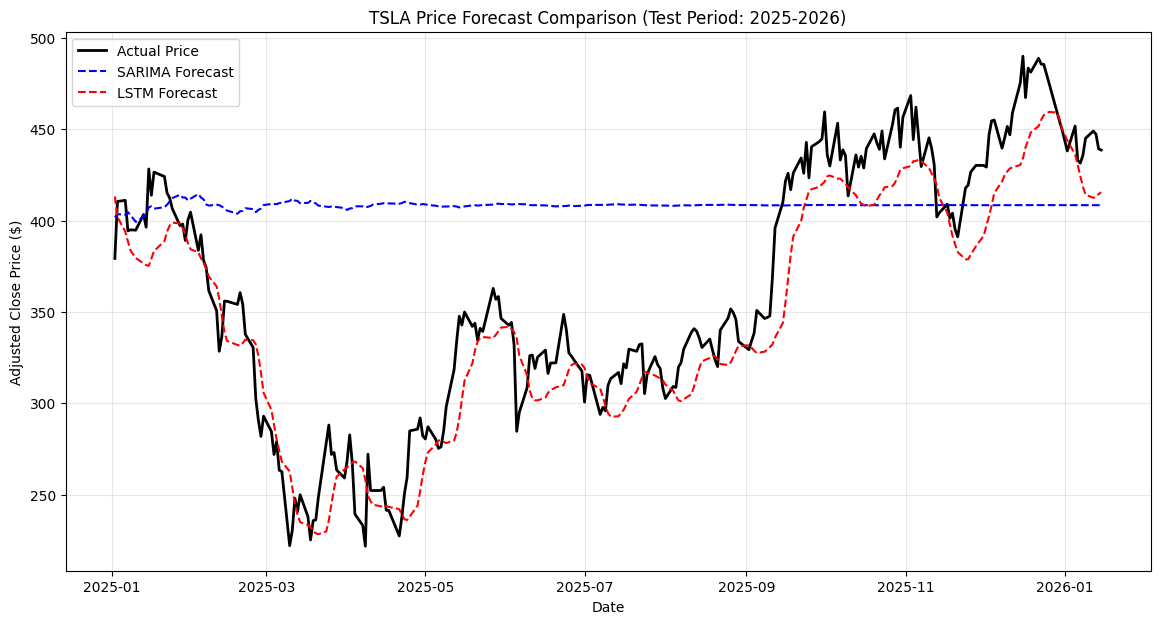

In [25]:
# Calculate metrics for both models
sarima_results = get_metrics(actual_prices, sarima_forecast, "SARIMA")
lstm_results = get_metrics(actual_prices, lstm_forecast, "LSTM")

# Create Comparison Table
comparison_df = pd.DataFrame([sarima_results, lstm_results])
print(comparison_df)

# Final Visualization
plt.figure(figsize=(14, 7))
plt.plot(test_df.index, actual_prices, label="Actual Price", color="black", linewidth=2)
plt.plot(test_df.index, sarima_forecast, label="SARIMA Forecast", color="blue", linestyle="--")
plt.plot(test_df.index, lstm_forecast, label="LSTM Forecast", color="red", linestyle="--")
plt.title("TSLA Price Forecast Comparison (Test Period: 2025-2026)")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()